<a href="https://colab.research.google.com/github/Imran1hp/YOLO-object-detection-model/blob/main/YOLOv8_Object_setection_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Download the Dataset from google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
file_path ="/content/drive/MyDrive/Waste_dataset_for_Yolov8"

In [3]:
import os
os.listdir(file_path)

['Waste.yolov8.zip',
 'README.roboflow.txt',
 'dataset',
 'data.yaml',
 'train',
 'valid',
 'test']

In [4]:
# import zipfile

# zip_file_path = os.path.join(file_path, 'Waste.yolov8.zip')

# # Ensure the zip file exists before attempting to extract
# if os.path.exists(zip_file_path):
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         zip_ref.extractall(file_path)
#     print(f"Unzipped {zip_file_path} to {file_path}")
# else:
#     print(f"Zip file not found at {zip_file_path}")

In [5]:
# os.rename('/content/drive/MyDrive/Waste_dataset_for_Yolov8/train' ,'/content/drive/MyDrive/Waste_dataset_for_Yolov8/dataset')

In [6]:
os.listdir(file_path)

['Waste.yolov8.zip',
 'README.roboflow.txt',
 'dataset',
 'data.yaml',
 'train',
 'valid',
 'test']

In [7]:
data_path =  os.path.join(file_path , 'dataset')
os.listdir(data_path)

['images', 'labels']

In [8]:
data_path

'/content/drive/MyDrive/Waste_dataset_for_Yolov8/dataset'

# Split and creat the valid and test files

In [9]:
import os
import random
import shutil

random.seed(42)

image_path = data_path +"/images"
label_path = data_path +"/labels"


for folder in ['train', 'valid', 'test']:
    shutil.rmtree(os.path.join(file_path, folder), ignore_errors=True)

os.makedirs(file_path + "/train/images" , exist_ok = True)
os.makedirs(file_path + "/train/labels" , exist_ok =True)

os.makedirs(file_path + "/valid/images" , exist_ok = True)
os.makedirs(file_path + "/valid/labels" , exist_ok = True)

os.makedirs(file_path + "/test/images" ,exist_ok= True)
os.makedirs(file_path + "/test/labels" , exist_ok = True)

images = os.listdir(image_path)
random.shuffle(images)


train_ratio = 0.7
valid_ratio = 0.2
test_ratio = 0.1
total = len(images)

train_end = int(total * train_ratio)
valid_end = train_end + int(total * valid_ratio)

train_files = images[:train_end]
valid_files = images[train_end:valid_end]
test_files = images[valid_end:]

In [10]:
image_path

'/content/drive/MyDrive/Waste_dataset_for_Yolov8/dataset/images'

In [11]:
def copy_files(file_list , target_folder):
  for img_file in file_list:

    label_file = os.path.splitext(img_file)[0]+'.txt'

    source_image_path = os.path.join(image_path , img_file)
    target_image_path = os.path.join(file_path ,target_folder , 'images',img_file)

    source_label_path = os.path.join(label_path , label_file)
    target_label_path = os.path.join(file_path ,  target_folder ,"labels" ,label_file)

    shutil.copy(source_image_path, target_image_path)
    shutil.copy(source_label_path, target_label_path)
  print(f"{target_folder} split complete")

In [12]:
copy_files(train_files , "train")
copy_files(valid_files ,"valid" )
copy_files(test_files , "test")

train split complete
valid split complete
test split complete


In [13]:
len(images)

2522

In [14]:
len(test_files)

253

In [15]:
len(train_files)

1765

In [16]:
len(valid_files)

504

In [17]:
len(test_files)

253

#filter the files with proper labels

#Install the YOlO model from Ultralytics

In [18]:
!pip install ultralytics --quiet

In [19]:
from ultralytics import YOLO


#Train model_0 ="yolov8n.pt" with imgsize = 640 , epochs=10

In [20]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Model moved to {device}")

Model moved to cuda


In [21]:
# from ultralytics import YOLO
# import os


# model_0 = YOLO('yolov8n.pt')
# model_0.to('cuda')

# model_0.train(data=os.path.join(file_path, 'data.yaml')
# , epochs=10, imgsz=640,
#   patience=50,
#   name ='model_0',
#   project = '/content/drive/MyDrive/Trained_models'
# )

#Predict using Model_0

In [22]:
trained_models_path = "/content/drive/MyDrive/Trained_models"

In [23]:
model_0_path  = "/content/drive/MyDrive/Trained_models/model_0-2/weights/best.pt"

In [24]:
test_img_path = os.path.join(file_path , "test", 'images')
test_img_path

'/content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images'

In [25]:
os.listdir(test_img_path)

['plastic68_jpg.rf.xTepjpJmE7JsXo2PraCe.jpg',
 'cardboard7_jpg.rf.VguutHNohrubCzeN9dbJ.jpg',
 'paper557_jpg.rf.tQ0MGpxCeMEyuhTCtagw.jpg',
 'metal165_jpg.rf.HPCGEka1vbozjZdtEBmn.jpg',
 'trash124_jpg.rf.0XNX42XaXR0tTAvu3mP4.jpg',
 'metal310_jpg.rf.ewQux7ewnLmR6zSLD9FX.jpg',
 'glass429_jpg.rf.Qly4kjCpir6415CgPtfg.jpg',
 'paper133_jpg.rf.E3oLAxlr8o5I93sx6AjF.jpg',
 'glass270_jpg.rf.q4JgoxJAAqkyMDGdfqIH.jpg',
 'metal214_jpg.rf.WeRt8Cf5dJvIgxeBNKT7.jpg',
 'paper75_jpg.rf.WXvxo9h7InTbVZq0A0j6.jpg',
 'metal287_jpg.rf.lwiwtn6AKOB7jUMPkSZY.jpg',
 'paper458_jpg.rf.BmurRMkwG5Ea9daezZ4i.jpg',
 'plastic450_jpg.rf.KCh8G2suYkKgnDFaorTa.jpg',
 'paper64_jpg.rf.xSFITBwG6IOEPADBv9aM.jpg',
 'paper542_jpg.rf.nUqJTxIyPoMbEKpyhabx.jpg',
 'plastic406_jpg.rf.3aCdwKShH15nlG9qcMLh.jpg',
 'metal113_jpg.rf.htpl6ZUExv71uRcVP0LH.jpg',
 'glass480_jpg.rf.lWUS7TnA7xOTMX27D1V3.jpg',
 'paper39_jpg.rf.uvs4HzoVArlWeYlYsc4Y.jpg',
 'paper549_jpg.rf.c1EPdY5drHhpacDaldts.jpg',
 'paper162_jpg.rf.9gizIZjvDcOvJgg1ctvW.jpg',
 'card

In [26]:
model_0 = YOLO(model_0_path)

In [27]:
result = model_0.predict(
    source = test_img_path,
    save = True
)


image 1/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard10_jpg.rf.6n4x8AcOWnHOk9MwdY5p.jpg: 480x640 1 cardboard, 70.1ms
image 2/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard115_jpg.rf.bCC3Ptk4ZTUtQoCGRsJp.jpg: 480x640 1 cardboard, 8.4ms
image 3/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard116_jpg.rf.JzCUchwIrLHeulxZvVEb.jpg: 480x640 1 cardboard, 26.5ms
image 4/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard12_jpg.rf.tl4pmbolrBQbK0oV6qSe.jpg: 480x640 1 cardboard, 6.8ms
image 5/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard130_jpg.rf.tGSIJeaIQndW9CZ6GGmd.jpg: 480x640 1 cardboard, 6.5ms
image 6/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard135_jpg.rf.dNTBtCBxGJ74xRp41hp1.jpg: 480x640 1 cardboard, 6.6ms
image 7/253 /content/drive/MyDrive/Waste_dataset_for_Yolov8/test/images/cardboard13_jpg.rf.TDJvNSpSpLixtUQ4MF2I.jpg: 480x640 1 ca

metal286_jpg.rf.X6VhvRdX0Sojk0eOQxot.jpg


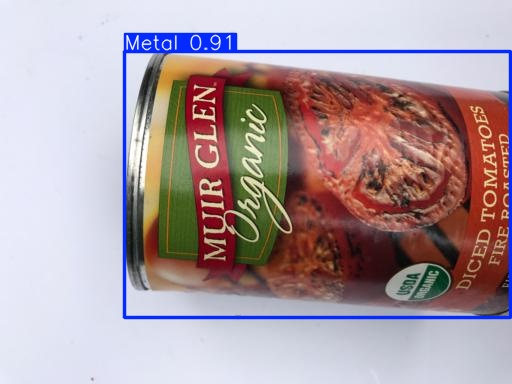

cardboard213_jpg.rf.gYzcO35moaa5nkCvm8Vk.jpg


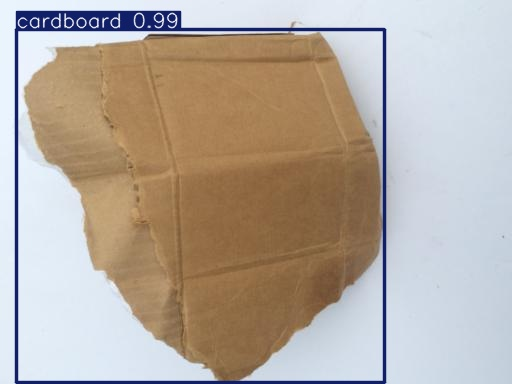

metal391_jpg.rf.Msd8Fpw3TzAsSG2iLdR2.jpg


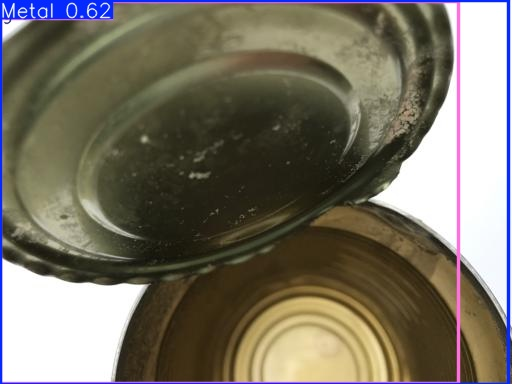

plastic142_jpg.rf.wDp1r4wuSelEVTvXSs0U.jpg


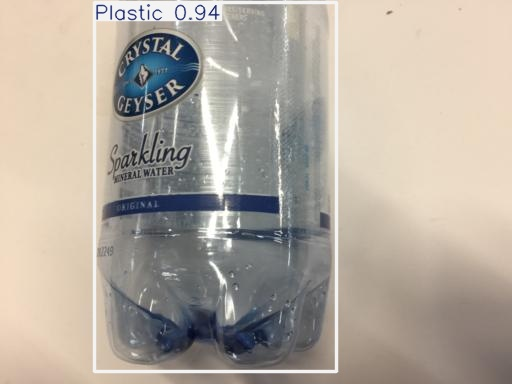

cardboard148_jpg.rf.qX0o2vNOrpDY9i3LauKo.jpg


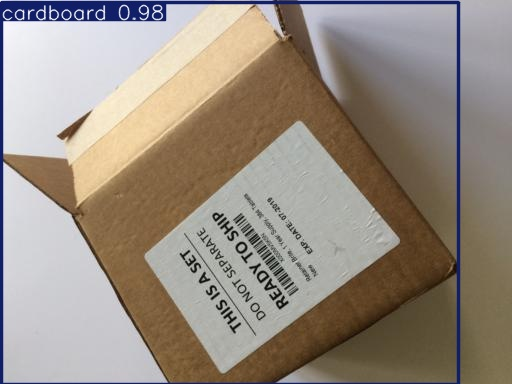

paper312_jpg.rf.0r0OtmkcuedIjDsAh96W.jpg


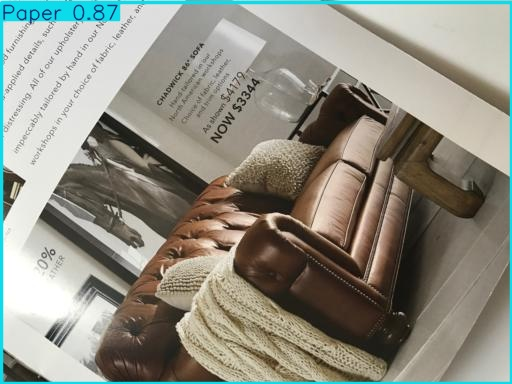

plastic461_jpg.rf.mEoXAOvpmt9YvqySDRa0.jpg


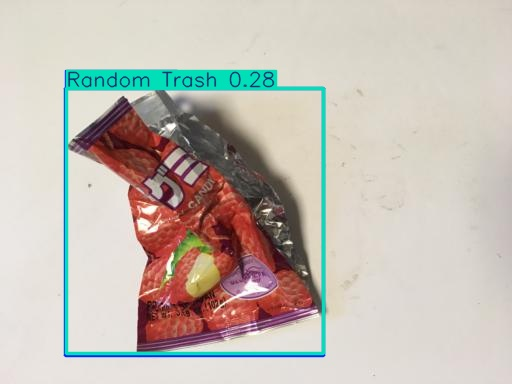

cardboard7_jpg.rf.VguutHNohrubCzeN9dbJ.jpg


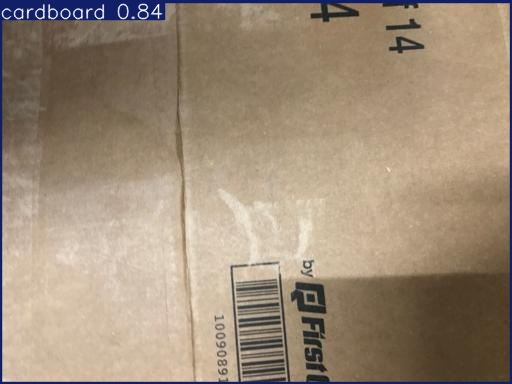

paper104_jpg.rf.xzHGAYp9vdfR3APRlI3F.jpg


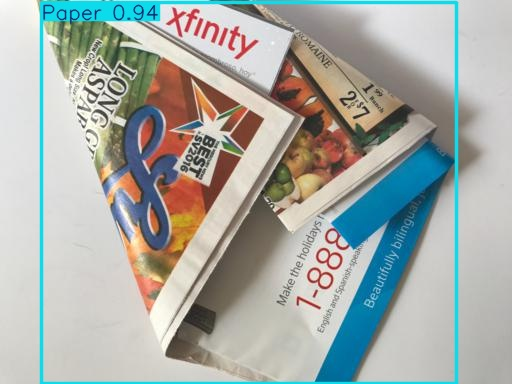

cardboard268_jpg.rf.LfGkwlRxHxdsQhPmwkS7.jpg


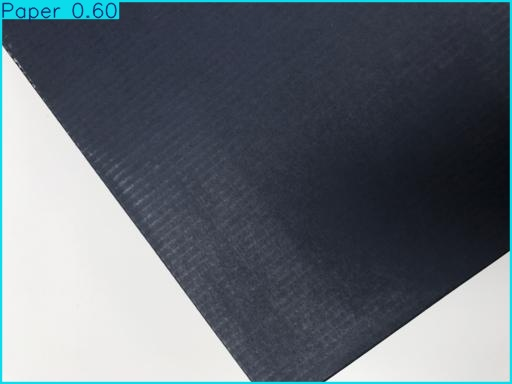

In [28]:
import os
import random
from IPython.display import Image, display

# Path of predicted images
predict_folder = '/content/runs/detect/predict'

# Get image files
images = [f for f in os.listdir(predict_folder)
          if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select random 10 images
random_images = random.sample(images, min(10, len(images)))

# Display images
for img in random_images:
    print(img)
    display(Image(filename=os.path.join(predict_folder, img)))

#Traing model_1 with  50 epochs

In [29]:
model_1 = YOLO("yolov8n.pt")
model_1.to(device)

model_1.train(

 data=os.path.join(file_path, 'data.yaml'),
 epochs=50,
 imgsz=640,
 patience=50,
 name ='model_1',
 project = '/content/drive/MyDrive/Trained_models'

)

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Waste_dataset_for_Yolov8/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plots=True, pose=12.0, pretrained=Tr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78f76ae76540>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     